# **Curated Knowledge, Contest Concepts: Experimenting RAG on the Fine Line between Femvertising and Femwashing**

*Femvertising*, advertising that employs pro-female talents, messages, and imagery to empower women, is distinguished from *femwashing* primarily by its authenticity. According to scholars such as Hainneville et al. (2023), the distinction between these two concepts is not a clear-cut binary, but rather a fine line shaped by holistic assessments across multiple dimensions.

This conceptual complexity presents a compelling challenge for a RAG-enabled LLM. Guided by the central research question: “**How does a RAG-enabled LLM navigate tasks that involve normatively complex socio-ethical concepts; specifically, the fine line between femvertising and femwashing?**”, this project conducts a mini experiment to push the model beyond surface-level pattern recognition.

Integrating a corpus of recent academic literature on femvertising and femwashing into the retrieval pipeline, the model will be given a series of tasks that assess its ability to generate responses fully grounded in the scholarly findings. The objective is to investigate whether a RAG-enabled large language model can meaningfully operationalise academic discourse to distinguish authentic femvertising from femwashing, rather than defaulting to generic empowerment rhetoric.

The Python code used in this experiment was structured with reference to the in-class materials from the *Data in Practice* module (Big Data in Culture & Society MA, King's College London) led by Dr. Mark Gotham and Dr. Mark Hill.  

In [2]:
# Setup & Installation

%pip install sentence-transformers scikit-learn

import numpy as np
import json
from pathlib import Path
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Data directory for caching processed corpora
DATA_DIR = Path ("data")
DATA_DIR.mkdir(exist_ok = True)

print(f"Data directory: {DATA_DIR.absolute()}")
print("Setup complete")

Data directory: /content/data
Setup complete


**Corpus Loading**

The project uses a custom academic corpus on femvertising and femwashing, consisting of five papers:

**R1. Hainneville et al. (2023)** Femvertising or Femwashing? Women's perceptions of authenticity.

**R2. Papadopoulou et al. (2025)** Diversity in Femvertising: An Experimental Investigation.

**R3. Abreu & Duarte (2025)** Femvertising or Femwashing? A Theoretical Perspective on the Impact of Authenticity on Purchase Intentions.

**R4. Buckley et al (2024)** Guilty Displeasures? How Gen-Z Women Perceive (In)Authentic Femvertising Messages.

**R5. Iyer & Dani (2025)** Femvertising empowering or commodifying women? Exploring the changing feminist discourse in internationally award-winning advertisements.

The corpus text file loaded onto the notebook will be parsed into individual paper-level documents. Using Python’s re module, the raw text is split on (Reading N) markers via a lookahead regular expression, which splits at each marker without consuming it. The resulting blocks are then parsed into structured document objects, each containing the full paper text, a title string extracted from the second non-empty line of the block, and a source label(= title).

In [4]:
import re

# identifier used for cache filenames
CORPUS_CACHE = "femvertising_femwashing"

# Load the corpus text file
CORPUS_PATH = "Academic_Corpus.txt"

with open (CORPUS_PATH, "r", encoding = "utf-8") as f:
  raw_text = f.read()

# Split into individual document on the (Reading N) markers
paper_blocks = re.split(r'(?=\((?:R)eading \d+\))', raw_text)
paper_blocks = [
    b.strip() for b in paper_blocks
    if b.strip().startswith("(Reading")
]

documents = []
for block in paper_blocks:
  lines = [l.strip() for l in block.splitlines() if l.strip()]
  title = lines[1] if len(lines) > 1 else lines[0]  # second non-empty line = paper title
  documents.append({
      "text": block,
      "title": title[:120],
      "source": title[:120]
  })

print(f"Loaded {len(documents)} documents from corpus")
for i, doc in enumerate(documents):
  print(f"  [{i+1}] {doc['title'][:90]}")

Loaded 5 documents from corpus
  [1] Femvertising or femwashing? Women's perceptions of authenticity
  [2] Diversity in Femvertising: An Experimental Investigation
  [3] Femvertising or Femwashing? A Theoretical Perspective on the Impact of Authenticity on Con
  [4] Guilty Displeasures? How Gen-Z Women Perceive (In)Authentic Femvertising Messages
  [5] Femvertising empowering or commodifying women? Exploring the changing feminist discourse i


**Model Loading**

For document embedding, **sentence-transformers/all-mpnet-base-v2** model was selected over all-MiniLM-L6-v2 which was used in module exercises. While both models belong to the same sentence-transformers family, all-mpnet-base-v2 is a larger model that produces 768-dimensional embeddings compared to MiniLM’s 384 dimensions. For an academic corpus where domain-specific terms carry high theoretical meanings distinct from their everyday usage, this richer semantic representation was considered more suitable.

For answer generation, **Gemini via Colab's built-in google.colab.ai** interface. Gemini is natively accessible within Colab without requiring model downloads or significant runtime memory, making it a practical choice for this project.

In [5]:
# Embedding model
EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v2"

print(f"Loading embedding model: {EMBEDDING_MODEL}")
embedder = SentenceTransformer(EMBEDDING_MODEL)
print(f"Embedding dimension: {embedder.get_sentence_embedding_dimension()}")

# Generation model
from google.colab import ai as colab_ai

print("Generation model: Gemini (google.colab.ai)")

Loading embedding model: sentence-transformers/all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_1551/3025910088.py:6: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding dimension: {embedder.get_sentence_embedding_dimension()}")


Embedding dimension: 768
Generation model: Gemini (google.colab.ai)


**Embedding / Chunking**

The embedding model, all-mpnet-base-v2, has a maximum input length of 384 tokens (approximately 1,500 characters). The chunk size was deliberately set as smaller (800 characters) than this for two reasons.

First, academic prose tends to have high sentence length and terminology density; a 800-character limit provides a conservative safety margin against truncation. Second, each paper in the corpus elaborates multi-dimensional concepts and claims across multiple sections. It was hypothesised that smaller chunks would increase the likelihood that a single vector represents one coherent theoretical point, enabling more precise matching between query and retrieved content.

To preserve the semantic integrity of each chunk as far as possible, a 100-character overlap was applied in chunking. Also, the chunking function used a priority-ordered separator that first attempts to break at paragraph boundaries (\n\n), then at line breaks (\n), punctuations (., ?, !), and finally at word boundaries (spaces).

In [6]:
# This cell chunks every document, generating an embedding vector for each chunk.

CHUNK_SIZE = 800
CHUNK_OVERLAP = 100

def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    """Split text into overlapping chunks at paragraph/sentence boundaries where possible."""
    if len(text) <= chunk_size:
        return [text]
    chunks_out, start = [], 0
    while start < len(text):
        end = start + chunk_size
        if end < len(text):
            for sep in ['\n\n', '\n', '. ', '? ', '! ', ' ']:
                pos = text.rfind(sep, start + chunk_size // 3, end)
                if pos != -1:
                    end = pos + len(sep)
                    break
        end = max(end, start + 1)  # guard against infinite loop
        chunk = text[start:end].strip()
        if chunk:
            chunks_out.append(chunk)
        start = end - overlap
    return chunks_out

# Cache paths
cache_key       = f"{CORPUS_CACHE}_{CHUNK_SIZE}_{CHUNK_OVERLAP}"
embeddings_file = DATA_DIR / f"{cache_key}_embeddings.npy"
chunks_file     = DATA_DIR / f"{cache_key}_chunks.json"

# Chunk, embed, and cache
if embeddings_file.exists() and chunks_file.exists():
    print(f"Loading cached embeddings ({cache_key})...")
    chunk_embeddings = np.load(embeddings_file)
    with open(chunks_file, "r") as f:
        cache_data     = json.load(f)
        chunks         = cache_data["chunks"]
        chunk_metadata = cache_data["metadata"]
    print(f"Loaded {len(chunks)} chunks with embeddings")
else:
    chunks, chunk_metadata = [], []
    for doc_idx, doc in enumerate(documents):
        for chunk_idx, chunk in enumerate(chunk_text(doc["text"])):
            chunks.append(chunk)
            chunk_metadata.append({
                "doc_idx":   doc_idx,
                "chunk_idx": chunk_idx,
                "title":     doc.get("title",  "Unknown"),
                "source":    doc.get("source", "Unknown"),
            })
    avg_chars = np.mean([len(c) for c in chunks])
    print(f"Created {len(chunks)} chunks - avg {avg_chars:.0f} chars (~{avg_chars/4:.0f} tokens)")

# Embed
    print(f"Embedding {len(chunks)} chunks with {embedder.get_sentence_embedding_dimension()}d vectors...")
    chunk_embeddings = embedder.encode(chunks, show_progress_bar=True, convert_to_numpy=True)

# Cache to disk
    np.save(embeddings_file, chunk_embeddings)
    with open(chunks_file, "w") as f:
        json.dump({"chunks": chunks, "metadata": chunk_metadata}, f)
    print("Embeddings cached for future runs.")

print(f"\nEmbedding matrix: {chunk_embeddings.shape}  "
      f"({chunk_embeddings.shape[0]} chunks × {chunk_embeddings.shape[1]} dims)")

Created 407 chunks - avg 599 chars (~150 tokens)
Embedding 407 chunks with 768d vectors...


/tmp/ipykernel_1551/4025301533.py:55: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Embedding {len(chunks)} chunks with {embedder.get_sentence_embedding_dimension()}d vectors...")


Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Embeddings cached for future runs.

Embedding matrix: (407, 768)  (407 chunks × 768 dims)


In [7]:
# Each chunk of test is now a vector of 768 numbers.
# These numbers encode the semantic meaning of the text.
# Similar texts will have similar vectors (high cosine similarity).

# Peek at an embedding
print("First chunk text (truncated):")
print(chunks[0][:100] + "...")
print()
print("Its embedding (first 20 dimensions):")
print(chunk_embeddings[0][:20])

First chunk text (truncated):
(Reading 1)
Femvertising or femwashing? Women's perceptions of authenticity


Valentine Hainneville ...

Its embedding (first 20 dimensions):
[ 0.03267267  0.06652169 -0.01521126 -0.04261936  0.01518027  0.02398632
  0.00684595 -0.06370828  0.03042234 -0.03459558 -0.00973571 -0.06220993
  0.02203777  0.04299927 -0.00899979  0.0048191  -0.02236382  0.0537665
  0.03372658  0.00748443]


**Test Retrieval (without Generation)**

Prior to generation, a diagnostic query was given to the RAG pipeline to test whether it could accurately retrieve the central theoretical framework of the corpus: the *six dimensions of authentic femvertising* outlined in R1.

In [8]:
def retrieve(query: str, top_k: int = 5) -> list[dict]:
    """
    Retrieve the top-k most similar chunks for a query.

    Returns a list of dicts with 'text', 'score', and metadata.
    """
    # Embed the query
    query_embedding = embedder.encode([query], convert_to_numpy=True)

    # Compute similarity with all chunks
    similarities = cosine_similarity(query_embedding, chunk_embeddings)[0]

    # Get top-k indices
    top_indices = np.argsort(similarities)[-top_k:][::-1]

    # Build results
    results = []
    for idx in top_indices:
        results.append({
            "text":  chunks[idx],
            "score": float(similarities[idx]),
            **chunk_metadata[idx]
        })

    return results

In [9]:
# Test Retrieval

query = "six dimensions of authentic femvertising"

print(f"QUERY: {query}")
print("=" * 100)

results = retrieve(query, top_k=5)

for i, result in enumerate(results):
  print(f"\n--- Result {i+1} (score: {result['score']:.3f}) ---")
  print(f"Source: {result['title']}")
  text_preview = result['text'][:300]
  print(f"Text: {text_preview}..." if len(result['text']) > 300 else f"Text: {result['text']}")

  print("\n")

QUERY: six dimensions of authentic femvertising

--- Result 1 (score: 0.500) ---
Source: Diversity in Femvertising: An Experimental Investigation
Text: ally, the perception of femvertising was uniform across all 6 advertisements (MD = 5.06, SD = 1.77,
MH = 4.93, SD = 1.70; F(1, 198) = 0.51, p = 0.48) The results confirmed that our diversity manipulation was effective as intended (see Table A2, Appendix A for full details). None of
the control varia...



--- Result 2 (score: 0.455) ---
Source: Femvertising or femwashing? Women's perceptions of authenticity
Text: perspective, explore the nature of authentic femvertising, and differentiate it from femwashing.


This research contributes to the literature in several ways. First, it offers a conceptualization of femvertising from a consumer perspective, something currently missing from the literature, through s...



--- Result 3 (score: 0.454) ---
Source: Femvertising or femwashing? Women's perceptions of authenticity
Text: , femvertising

The test query, “six dimensions of authentic femvertising”, produced an unexpected result: it retrieved irrelevant chunks from R2’s Results section. Given that the term “six dimensions” appeared ten times in R1 and zero times in R2, this outcome required further analysis. To investigate why the query was mapped into the wrong semantic region, three phrasing variants of the query were tested against the same retrieval target.

In [10]:
# Original query + 3 phrasing variants, asking about the same concept.
# Only the top result (title + score) is shown — the question is whether phrasing
# changes *which document* the model would receive as context.

concept = "femvertising vs femwashing"
phrasings = [
    "six dimensions of authentic femvertising",
    "the six dimensions of authentic femvertising",
    "the six conceptual dimensions of authentic femvertising",
    "the six conceptual dimensions of authentic femvertising from a consumer perspective"
]

print(f'Concept: "{concept}" — four phrasings, four retrievals')
print("=" * 70)
print(f"  {'Phrasing':<44} {'Top result':<28} Score")
print("  " + "-" * 66)

seen_titles = set()
for phrase in phrasings:
    r = retrieve(phrase, top_k=1)[0]
    marker = "  <-- same" if r["title"] in seen_titles else ""
    seen_titles.add(r["title"])
    print(f"  {phrase[:43]:<44} {r['title'][:43]:<44} {r['score']:.3f}{marker}")

Concept: "femvertising vs femwashing" — four phrasings, four retrievals
  Phrasing                                     Top result                   Score
  ------------------------------------------------------------------
  six dimensions of authentic femvertising     Diversity in Femvertising: An Experimental   0.500
  the six dimensions of authentic femvertisin  Femvertising or femwashing? Women's percept  0.649
  the six conceptual dimensions of authentic   Femvertising or femwashing? Women's percept  0.810  <-- same
  the six conceptual dimensions of authentic   Femvertising or femwashing? Women's percept  0.870  <-- same


The most revealing finding was that adding the definite article "the" alone corrected the retrieval (R2 -> R1) and increased the similarity score (0.500 -> 0.649). This may be becuase it signalled a specific, established framework rather than a generic phrase, thereby shifting the embedding toward a more precise semantic region while increasing its similarity to the correct chunk.

Subsequent additions of "conceptual" and "from a consumer perspective" further increased similarity scores. These terms may have functioned as domain anchor terms that closely mirrored R1's language, helping position the query closer to the retrieval target.

Visualisation function defined (with similar AND dissimilar chunks)
Projecting to 2D with t-SNE (this may take a moment)...


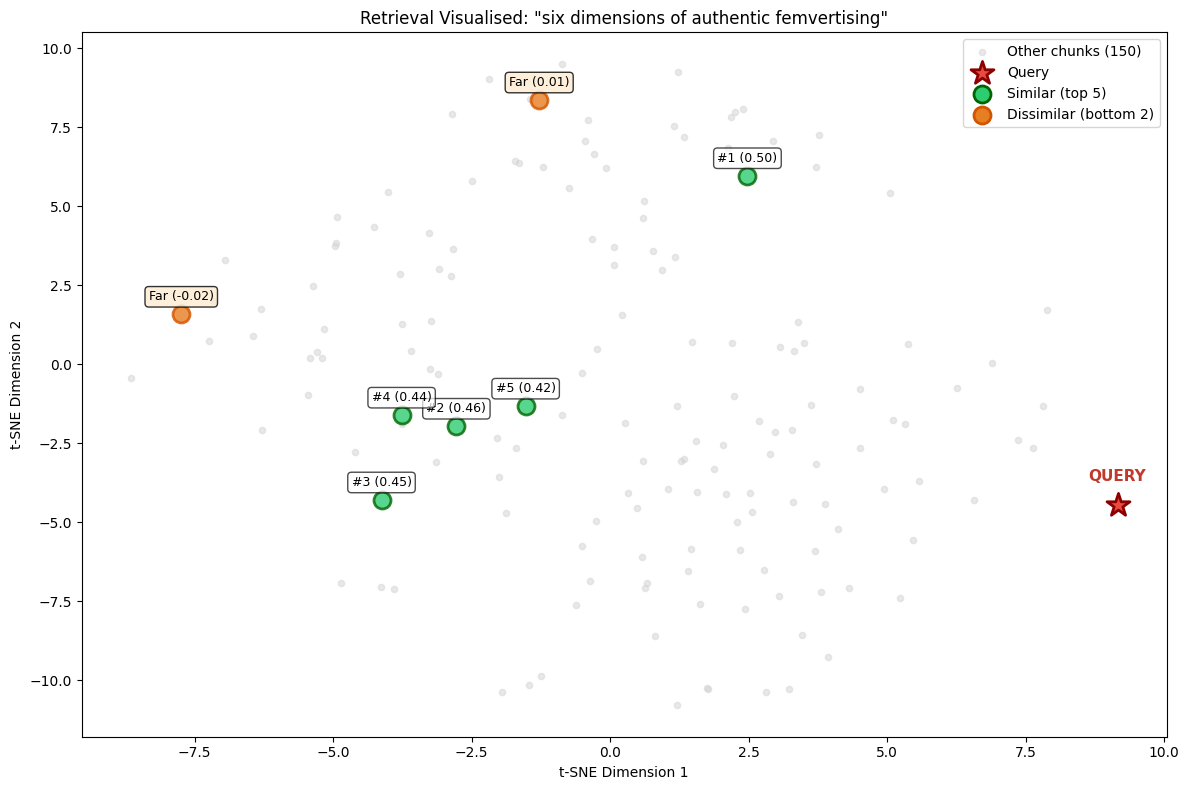


SIMILAR chunks (nearest neighbours - would be retrieved):

  #1 (similarity: 0.500)
     ally, the perception of femvertising was uniform across all 6 advertisements (MD...

  #2 (similarity: 0.455)
     perspective, explore the nature of authentic femvertising, and differentiate it ...

  #3 (similarity: 0.454)
     , femvertising cannot be authentic if it involves sexualized messages submitted ...

  #4 (similarity: 0.441)
     and the gap between what consumers perceive as femvertising and what they percei...

  #5 (similarity: 0.425)
     its core principles of promoting empowerment and embracing diversity to realize ...

------------------------------------------------------------
DISSIMILAR chunks (far away - would NOT be retrieved):

  (similarity: -0.017)
     reputation and degree of social commitment, as well as their awareness of the so...

  (similarity: 0.007)
     ) (see Figure 2). None of the demographic factors had any significant effects on...
Projecting to 2D with t-

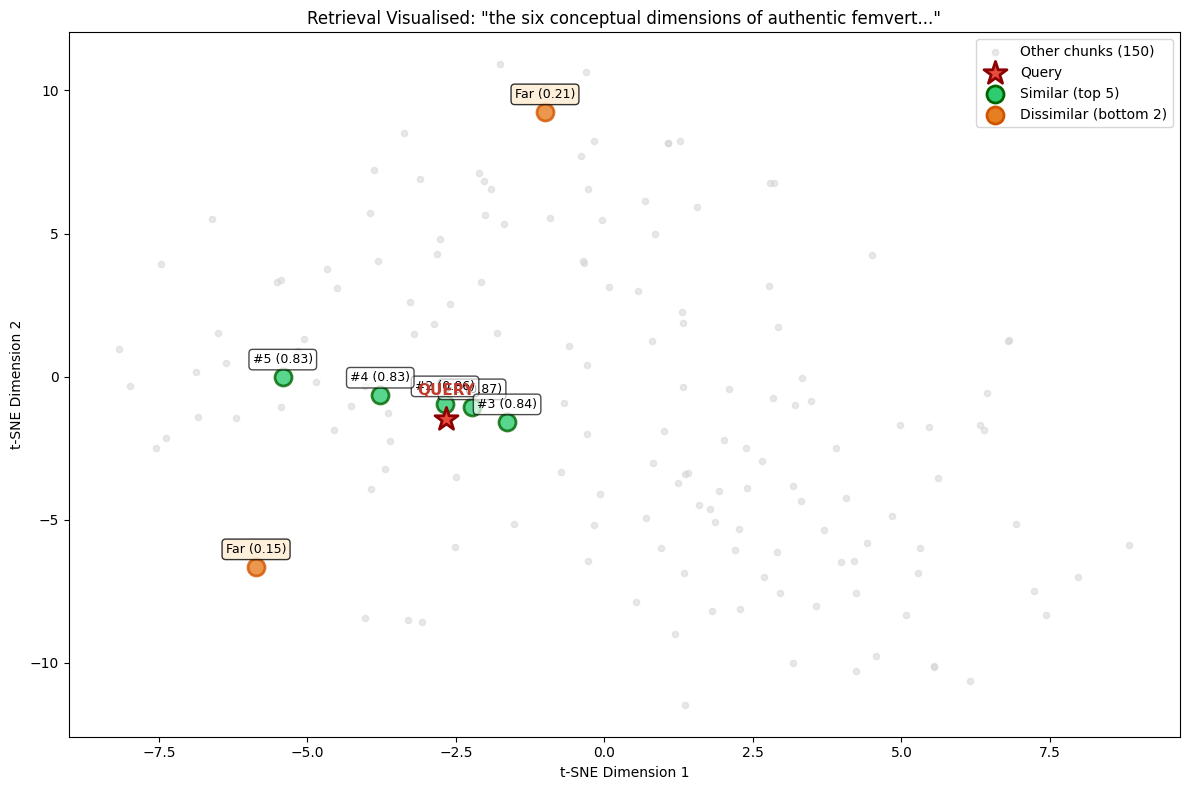


SIMILAR chunks (nearest neighbours - would be retrieved):

  #1 (similarity: 0.870)
     perspective, explore the nature of authentic femvertising, and differentiate it ...

  #2 (similarity: 0.857)
     and the gap between what consumers perceive as femvertising and what they percei...

  #3 (similarity: 0.840)
     ownplaying sexuality, and authentic portrayals) according to marketing professio...

  #4 (similarity: 0.830)
     been doing shit for 50 years, we are sorry, we're going to start over’” – Aureli...

  #5 (similarity: 0.828)
     esk, she's creating something, to me it is more authentic, it looks like a littl...

------------------------------------------------------------
DISSIMILAR chunks (far away - would NOT be retrieved):

  (similarity: 0.154)
     for positive societal change.


________________


________________...

  (similarity: 0.215)
     s, participants in the two diverse conditions reported greater perceptions of di...


In [11]:
# Visualising Retrieval in Vector Space

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualise_retrieval(query: str, top_k: int = 5, bottom_k: int = 2, n_background: int = 200):
    """
    Visualise how retrieval works by plotting query and chunks in 2D space.

    Shows:
    - Query point (large, red star)
    - Retrieved chunks (green, labeled) - most similar to query
    - Dissimilar chunks (orange, labeled) - least similar to query
    - Random background chunks (grey, for context)
    """
    # Get query embedding
    query_embedding = embedder.encode([query], convert_to_numpy=True)

    # Get retrieval results - both most and least similar
    similarities   = cosine_similarity(query_embedding, chunk_embeddings)[0]
    top_indices    = np.argsort(similarities)[-top_k:][::-1]   # Most similar
    bottom_indices = np.argsort(similarities)[:bottom_k]        # Least similar

    # Sample random background chunks (excluding top and bottom)
    all_indices      = set(range(len(chunks)))
    excluded         = set(top_indices) | set(bottom_indices)
    background_indices = list(all_indices - excluded)
    np.random.seed(42)
    background_sample = np.random.choice(
        background_indices,
        size=min(n_background, len(background_indices)),
        replace=False
    )

    # Combine all points for t-SNE: query, top-k, bottom-k, background
    indices_to_plot    = list(top_indices) + list(bottom_indices) + list(background_sample)
    embeddings_to_plot = np.vstack([
        query_embedding,
        chunk_embeddings[indices_to_plot]
    ])

    # Reduce to 2D
    print("Projecting to 2D with t-SNE (this may take a moment)...")
    tsne      = TSNE(n_components=2, random_state=42, perplexity=30)
    coords_2d = tsne.fit_transform(embeddings_to_plot)

    # Split coordinates
    query_coords     = coords_2d[0]
    retrieved_coords = coords_2d[1:top_k+1]
    dissimilar_coords = coords_2d[top_k+1:top_k+1+bottom_k]
    background_coords = coords_2d[top_k+1+bottom_k:]

    # Plot
    plt.figure(figsize=(12, 8))

    # Background chunks (grey, small)
    plt.scatter(background_coords[:, 0], background_coords[:, 1],
                c='lightgrey', s=20, alpha=0.5, label=f'Other chunks ({len(background_sample)})')

    # Dissimilar chunks (orange, medium, with labels)
    for i, (x, y) in enumerate(dissimilar_coords):
        score = similarities[bottom_indices[i]]
        plt.scatter(x, y, c='#e67e22', s=150, alpha=0.8, edgecolors='#d35400', linewidths=2)
        label = f"Far ({score:.2f})"
        plt.annotate(label, (x, y), fontsize=9, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='#fdebd0', alpha=0.8))

    # Retrieved chunks (green, medium, with labels)
    for i, (x, y) in enumerate(retrieved_coords):
        score = similarities[top_indices[i]]
        plt.scatter(x, y, c='#2ecc71', s=150, alpha=0.8, edgecolors='darkgreen', linewidths=2)
        label = f"#{i+1} ({score:.2f})"
        plt.annotate(label, (x, y), fontsize=9, ha='center', va='bottom',
                     xytext=(0, 8), textcoords='offset points',
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

    # Query point (red, large star)
    plt.scatter(query_coords[0], query_coords[1], c='#e74c3c', s=300,
                marker='*', edgecolors='darkred', linewidths=2, label='Query', zorder=10)
    plt.annotate('QUERY', (query_coords[0], query_coords[1]), fontsize=11,
                 fontweight='bold', ha='center', va='bottom',
                 xytext=(0, 15), textcoords='offset points',
                 color='#c0392b')

    # Add legend
    plt.scatter([], [], c='#2ecc71', s=150, edgecolors='darkgreen',
                linewidths=2, label=f'Similar (top {top_k})')
    plt.scatter([], [], c='#e67e22', s=150, edgecolors='#d35400',
                linewidths=2, label=f'Dissimilar (bottom {bottom_k})')
    plt.legend(loc='upper right', fontsize=10)

    plt.title(f'Retrieval Visualised: "{query[:50]}..."' if len(query) > 50 else f'Retrieval Visualised: "{query}"',
              fontsize=12)
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.tight_layout()
    plt.show()

    # Show what was retrieved AND what was dissimilar
    print("\n" + "=" * 60)
    print("SIMILAR chunks (nearest neighbours - would be retrieved):")
    for i, idx in enumerate(top_indices):
        print(f"\n  #{i+1} (similarity: {similarities[idx]:.3f})")
        print(f"     {chunks[idx][:80]}...")

    print("\n" + "-" * 60)
    print("DISSIMILAR chunks (far away - would NOT be retrieved):")
    for i, idx in enumerate(bottom_indices):
        print(f"\n  (similarity: {similarities[idx]:.3f})")
        print(f"     {chunks[idx][:80]}...")

print("Visualisation function defined (with similar AND dissimilar chunks)")

# Visualise retrieval
vis_query_1 = "six dimensions of authentic femvertising"
vis_query_2 = "the six conceptual dimensions of authentic femvertising from a consumer perspective"

visualise_retrieval(vis_query_1, top_k=5, n_background=150)
visualise_retrieval(vis_query_2, top_k=5, n_background=150)

The initial query’s retrieval failure may have been caused by the pipeline’s reliance on surface-level lexical similarity rather than deeper conceptual understanding. The incorrectly retrieved chunks from R2 included terms like “6 advertisements”, suggesting the token "six" might have triggered **numeric lexical attraction** where the model is drawn to any passage containing similar numerical patterns, even when the conceptual meaning is unrelated. This led to the query being mapped into a semantic dead zone in the vector space, weakly connected to the relevant conceptual cluster (as visualised above.)

This reflects a potential lexical bias in embedding models: assigning strong weight to salient tokens, such as numbers and repeated terms, rather than to the intended theoretical context. Overall, these findings demonstrate an epistemological weakness of RAG: it does not retrieve meaning itself, but rather **statistically similar representations of meaning**. As a result, small linguistic variations can significantly affect whether the model retrieves relevant knowledge or misleading contextual information.

**Retrieval-Augmented Generation (RAG) Assessment**

**Part A. Comprehension Testing**

The first part of the RAG assessment tested the model's comprehension of the femvertising-femwashing discourse outlined in the corpus. A structured set of questions (A1-A6) were given to the model to assess whether it could ground its responses in accurately retrieved scholarly findings.

In [12]:
from google.colab import ai

def generate_with_context(question: str, context: str) -> str:
  prompt = (
        "You are a helpful assistant. Answer the user's question based ONLY on the "
        "provided context. Give a detailed, well-reasoned answer — do not give a "
        "one-line summary. If the context doesn't contain enough information to answer, "
        "say 'The provided context doesn't contain this information.' "
        "Do not use any knowledge from outside the provided context.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n\n"
        "Answer in detail based only on the context above:"
    )
  return ai.generate_text(prompt)

def rag_answer(question: str, top_k: int = 3, show_context: bool = False) -> str:
    """
    Full RAG pipeline: retrieve then generate.

    Set show_context=True to inspect which chunks were fed to the model.
    """
    results = retrieve(question, top_k=top_k)

    context_parts = []
    for r in results:
        context_parts.append(f"[Source: {r['title']}]\n{r['text']}")

    context = "\n\n".join(context_parts)

    if show_context:
        print("=== RETRIEVED CONTEXT ===")
        for i, r in enumerate(results):
            print(f"\n[{i+1}] {r['title']} (score: {r['score']:.3f})")
            print(r['text'][:200] + "..." if len(r['text']) > 200 else r['text'])
        print("\n" + "=" * 50)

    return generate_with_context(question, context)


def ask_without_rag(question: str) -> str:
    """
    Ask the model directly without any retrieved context.
    Uses the same prompt structure as rag_answer for a fair comparison.
    """
    prompt = (
        "You are a helpful assistant. Give a detailed, well-reasoned answer.\n\n"
        f"{question}"
    )
    return ai.generate_text(prompt)


print("Generation functions defined.")

Generation functions defined.


In [13]:
# Comprehension Prompts (A1-A6)
prompts_A = {
    "A1": (
        "How do consumers distinguish between femvertising and femwashing?"
        ),
    "A2": (
        "Identify one advertising campaign that has been criticised as femwashing, "
        "and explain what specific features led to that assessment."
        ),
    "A3": (
        "What are the potential risks of tokenism regarding diversity in femvertising?"
        ),
    "A4": (
        "Does a femvertising slogan ‘Love your body’ genuinely contribute to female empowerment?"
        ),
    "A5": (
        "When and by whom was the term ‘femvertising’ coined?"
        ),
    "A6": (
        "For Gen-Z women, what factor(s) shape(s) their perceptions of femvertising messages?"
        )
}

for label, prompt in prompts_A.items():
  print(f"\n{'='*60}")
  print(f"PROMPT {label}: {prompt}")
  print("=" * 60)
  print(rag_answer(prompt, top_k=5, show_context=False))
  print()


PROMPT A1: How do consumers distinguish between femvertising and femwashing?
Based on the provided context, consumers distinguish between femvertising and femwashing primarily through their perception of authenticity.

The context indicates that "participants noticed the inauthenticity of some ads" when discussing perceptions of femwashing. Furthermore, it states that consumers began using the term "femwashing" on social media to "denounce inauthentic femvertising." This highlights that a lack of genuine intent or a perceived falsehood in advertising that aims to empower women is what leads consumers to identify it as femwashing.

The research itself contributes to understanding this distinction by offering a conceptualization of femvertising from a consumer perspective through six specific dimensions: transparency, consistency, identification, diversity, respect, and challenging stereotypes. While the context doesn't explicitly state that consumers *consciously* apply these six dimen

The responses overall showed coherent retrieval success, presumably since the prompts were formulated in terms that closely mirrored the corpus’s own conceptual language, in alignment with the findings from the previous retrieval testing. It was also found that RAG could meaningfully operationalise contested scholarly frameworks by integrating relevant findings across multiple documents, demonstrating a solid comprehension of the corpus.

The “partially grounded” response for A2 represents not a retrieval failure but a limitation in terms of precision; it did not fully meet the prompt’s intent to select a single specific advertising campaign. The model retrieved text at a higher level of generality than the prompt demanded, without acknowledging this gap. It also missed out on analytically richer cases such as Dove’s “Real Beauty” campaign in R1, which was evaluated against multiple dimension violations. This suggests that retrieval does not always surface the most substantively relevant content, and its granularity does not always align with the specificity demanded by the prompt. Had the prompt been more explicitly scoped (e.g. specifying the “named campaign” element), retrieval may have been redirected toward more granular, campaign-specific content.


**Part B. Advertising Scenario Task**

The subsequent part of the RAG assessment increased conceptual complexity by presenting the model with an advertising scenario task that required **(a) the creation of authentic femvertising copy** and **(b) a holistic assessment of the scenarised campaign**. The scenario was designed to embed multiple femwashing risk factors drawn from the corpus, requiring the model to draw on all six documents simultaneously. A fully grounded response would be expected not only to identify these risks in its critical assessment, but also to avoid reproducing them in the generated advertisement copy. This made it a more demanding test of whether RAG’s constraining effect operates at the level of creative generation in addition to discursive evaluation.

In [14]:
# Ad Generation Prompt

prompt_B = (
    "An activewear brand is preparing to launch an advertising campaign for their new leggings line. "
    "This product comes in pastel colourways and targets Gen-Z women. "
    "Until now, this brand focused solely on sales and performance in marketing, "
    "with no prior engagement with social causes or DEI initiatives. "
    "Seeking to widen its appeal among younger female audiences, they plan to deploy femvertising in their new campaign. "
    "The campaign film will feature models in their early 20s, of diverse ethnicities and body types. "
    "For the campaign slogan, the creative team has shortlisted the following candidates: "
    "'Soft in pink, Strong in sync', 'Embrace your line, Love every curve', 'Wear confidence, Own the moment', 'Sweat now, Shine later'. "
    "Draft a print advertisement copy for this campaign, selecting or adapting one of the slogans above. "
    "The copy, including the slogan, should be perceived as authentic femvertising by the target audience. "
    "Additionally assess whether this campaign would be perceived as genuinely empowering by the target audience, "
    "identifying any risks or problematic elements that may undermine the authenticity of femvertising. "
    "Keep your response to around 500 words."
)


print("RAG CONDITION")
print(f"\n{'=' * 60}")
print("=" * 60)
print(rag_answer(prompt_B, top_k=5, show_context=False))

RAG CONDITION

Here is the print advertisement copy and an assessment of the campaign's authenticity and risks:

**Print Advertisement Copy**

**Slogan:** Embrace your line, Love every curve.

**Body:**
Beyond the fabric, beyond the trend. Our new leggings line is crafted for your comfort, designed to move with every unique shape. We celebrate the strength in every stride and the beauty in every curve. This is about feeling good in your own skin, on your own terms. For every body, perfect fit, perfect comfort. Your confidence, your power, your moment.

---

**Assessment of Perceived Empowerment and Risks to Authenticity**

The proposed activewear campaign presents elements that could be perceived as genuinely empowering, alongside significant risks that may undermine its authenticity and lead to it being categorized as "femwashing" by the target audience.

**Potential for Perceived Empowerment:**
The campaign incorporates several aspects aligned with authentic femvertising. The decisio

While the model properly identified the femwashing indicators in relation to the consistency and transparency dimensions from R1, it failed to flag other elements: the post-feminist discourse elements in the shortlisted slogans (R5), the risk of tokensitic diveristy in model casting (R2), and Gen-Z specific considerations (R4). Regarding the generated advertising copy, the model selected the slogan verbatim without adaptation or critical acknowledgement of its post-feminist elements. It attempted to operationalise diversity and respect dimensions from R1, yet remained dominated by individualising language (“your confidence, your power, your moment”, “feeling good in your own skin, on your own terms”). This indicates the lack of corpus grounding based on R5.

The most analytically significant finding from this task was the gap between the model’s comprehension and generation performance. While the model could retrieve and articulate R2’s tokenism framework, R4’s Gen-Z specific theories, and R5’s post-feminist discourse critique in the previous task, none of these retrievals translated into the assessment and copy generation in this scenario task. This dissociation suggests that retrieval success in a direct question-answering context does not guarantee activation of the same content when the task is structurally different; specifically, when the model should simultaneously generate creative content and apply critical scholarly criteria to its own output. RAG’s architecture can supply relevant knowledge, but cannot compel the model to use that knowledge critically when the generative task involves open-ended interpretation. The fine line between femvertising and femwashing, which requires holistic, multi-dimensional assessment, is precisely the kind of interpretive judgment that pattern-based generation struggles to operationalise, even with retrieval augmentation.


**Conclusion**

This project set out to investigate whether a RAG-enabled LLM could meaningfully navigate the fine line between femvertising and femwashing; a normatively contested distinction that extends beyond surface-level pattern matching. The findings suggest that RAG partially delivers on this ambition, but with important qualifications.

Across three experimental stages, the pipeline demonstrated that retrieval augmentation can direct model outputs toward theoretically specific scholarly content when query formulation aligns with the corpus's conceptual language. The comprehension tasks confirmed that RAG can operationalise contested frameworks with meaningful accuracy. However, the retrieval testing stage revealed that this accuracy is lexically contingent: minor phrasing differences produced significant variation in retrieval precision, suggesting the pipeline responds to linguistic register rather than conceptual intent.

The most consequential finding emerged from the creative dual-task, where the gap between comprehension and generation performance was most pronounced. The model's reversion to generic empowerment rhetoric, despite having access to retrieved content that explicitly critiques such rhetoric, indicates that RAG cannot fully bridge the distance between supplying relevant knowledge and applying it critically within an open-ended generative task. This distinction matters; the femvertising–femwashing fine line is not a fact to be retrieved but a judgment to be exercised, and that remains beyond the current reach of RAG.

These findings counsel caution about deploying RAG-enabled LLMs in normatively sensitive creative contexts without human oversight. Retrieval augmentation narrows the gap between generic and grounded outputs, but does not close it. In domains where the stakes of getting the distinction wrong carry real social consequences, that remaining gap is not trivial. Future work might explore whether more granular corpus design, hybrid retrieval methods, or more explicit prompt scaffolding can further constrain generative tendencies in such contexts.
